# SECTION 1: Introduction and System Selection

Karthik Gunaseelan EID: kkg745, Emeric Famechon EID: ejf978, Project: 2-Person Group

For this project, I selected Mechanical System with High Damping (Option D). The physical system is an overdamped mechanical system, such as a shock absorber, vibration damper, or seismic isolation device. These systems are designed to reduce motion quickly, so they often have very large damping effects. The objective of this project is to compare explicit and implicit numerical methods for stiff equations and evaluate/analyze stability, accuracy, and computational cost. 

Since m is negligible, the governing ODE can be reduced from a second-order to a first-order. 

### Governing First-Order ODE:

$$\frac{dx}{dt} = -\frac{k}{c}x + \frac{1}{c}F(t)$$

### Parameters Used:

$$\frac{k}{c} = 5000 s^{-1} x$$

$$F(t) = 10sin(t) N $$

### Governing First-Order ODE Rewritten:

$$\frac{dx}{dt} = -5000x + .002sin(t)$$

### Physical Meanings:
- t: time (s)
- x(t): Displacement from equilibrium
- k: Spring constant (N/m)
- c: Damping coefficient (Ns/m)
- F(t): External force function

Because of the high damping rate, the mechanical system will be forced to return to equilibrium quickly, while the external force inputs slow dynamics once the system reaches the equilibrium point.

### Initial Condition:

$$x(0) = 1$$ 
This is an initial displacement of 1m from equilibrium in the spring-mass system.

### Importance of the System in Practice:

Overdamped mechanical systems have a wide variety of applications, such as shock absorbers, vibration dampers, and seismic location. Because these systems use fast and slow dynamics, they are considered numerically stiff. As a result, explicit methods like Euler's Forward require very small step sizes to remain stable, making them computationally inefficient. For this reason, implicit methods such as Euler's Backward are preferred when solving stiff differential equations.

To begin, Euler's Forward will be applied to illustrate the stiffness of the system. After that, Euler's Backward, which is Implicit Euler, will be implemented using the Newton-Raphson iteration to solve the residual equation at every time step.

# SECTION 2: Demonstrating Stiffness

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
t0 = 0 # Initial time (s)
tf = 3 # Final time (s)
x0 = 1.0 # Initial position (m)
h_values = [.5, 0.1, 0.01, 0.001, 0.0001] # Step sizes

# Function representing dx/dt = -5000x + 0.002sin(t)
def f(t, x):
    return -5000 * x + 0.002 * np.sin(t)

In [2]:
# Forward Euler method
def forward_euler(f, x0, t0, tf, h):
    
    # Create arrays to store t and y values
    t_values = np.arange(t0, tf + h, h)
    x_values = np.zeros_like(t_values)
    
    # Set initial condition
    x_values[0] = x0
    
    # Euler's Method loop
    for i in range(1, len(t_values)):
        x_values[i] = x_values[i-1] + h * f(t_values[i-1], x_values[i-1])
    
    return t_values, x_values

<ipython-input-1-bdd1a4b12fcb>:12: RuntimeWarning: overflow encountered in double_scalars
  return -5000 * x + 0.002 * np.sin(t)
<ipython-input-2-5c545ddda5e4>:13: RuntimeWarning: invalid value encountered in double_scalars
  x_values[i] = x_values[i-1] + h * f(t_values[i-1], x_values[i-1])


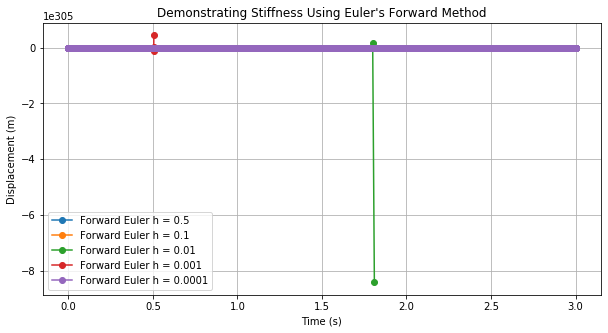

In [3]:
# Plot Forward Euler to demonstrate stiffness

plt.figure(figsize=(10, 5))

for h in h_values:
    
    t_values, x_values = forward_euler(f, x0, t0, tf, h)
    plt.plot(t_values, x_values, 'o-', label=f'Forward Euler h = {h}')

plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title("Demonstrating Stiffness Using Euler's Forward Method")
plt.legend()
plt.grid(True)
plt.show()

We tested the system using Euler's Forward Method with several step sizes. However, only the smallest step size, h = 0.0001, produced a stable solution. This shows that explicit methods require extremely small step sizes to converge when solving stiff systems.

Stiffness can also be confirmed by estimating the stiffness ratio, which is the ratio between the fastest to slowest time scales. The fastest time scale is: $\frac{1}{5000}=2*10^{-4}s$. This comes from the homogenous -5000x decay term of $\frac{dx}{dt} = -5000x+0.002sin(t)$. The slowest time scale is associated with the forcing term, sin(t), which varies over full seconds and can be approximated with a time scale of 1 second. As a result, the stiffness ratio is $\frac{1}{2*10^{-4}}$. This high stiffness ratio indicates that the system is stiff.

The Forward Euler stability condition is: $∣1+hλ∣≤1$. This simplifies to $h < \frac{2}{|λ|}$. Since the forcing term does not affect stability, we can assume that $λ=-5000$ from $\frac{dx}{dt} = -5000x$. So, the largest stable time step for Euler's Forward Method is h = 0.0004. Over a runtime of 5 seconds, this would require over 10,000 steps. Since Euler's Forward has a computational cost of 0(n), using such a small step size makes the method increasingly inefficient for longer simulations. To avoid the stability limitations with Euler's Forward, an implicit solution must be used instead.

# Section 3. Euler's Backward Method with Newton-Raphson

Residual Function in the Form:
$$g(x_{n+1}) = x_{n+1} - x_n - h(-5000x_{n+1}+0.002sin(t_{n+1}))$$
This can be derived into:
$$g'(x_{n+1})=1+5000h$$
Newton-Raphson Update Formula to Solve $g(x_{n+1})$:
$$x^{(k+1)}_{n+1} = x^{(k)}_{n+1} - \frac{g(x^{(k)}_{n+1})}{g'(x^{(k)}_{n+1})}$$

Substituting Residual Function and Its Derivative:

$$x^{(k+1)}_{n+1} = x^{(k)}_{n+1} - \frac{x^{(k)}_{n+1} - x_n - h(-5000x^{(k)}_{n+1}+0.002sin(x_{n+1})}{1+5000h}$$

In [4]:
# Governing ODE function

def f(t, x):
    return -5000*x + 0.002*np.sin(t)  

In [5]:
# Derivative of residual function

def g_prime(h):
    
    return 1 + h * 5000

In [6]:
# Newton-Raphson function
def newton_raphson(g, dg, x0, tol=1e-6, max_iter=20):
    # Initial guess
    x = x0
    
    # Newton-Raphson loop
    for i in range(max_iter):
        # Compute next iteration
        x_new = x - g(x) / dg(x)
        
        # Check for convergence
        if abs(x_new - x) < tol:
            return x_new, i + 1
        
        # Update x
        x = x_new

    return None, max_iter

In [7]:
# Backward Euler with Newton-Raphson

def backward_euler_newton(f, x0, t0, tf, h):
    
    # Create arrays to store t, x, and iteration count
    t_values = np.arange(t0, tf + h, h)
    x_values = np.zeros_like(t_values)
    iter_values = np.zeros_like(t_values)
    
    # Set initial conditions
    x_values[0] = x0
    iter_values[0] = 0
    
    # Backward Euler loop
    for i in range(1, len(t_values)):
        # Current values
        t_next = t_values[i]
        x_prev = x_values[i - 1]
        
        # Define g and dg for Newton-Raphson
        g = lambda x_next: x_next - x_prev - h * f(t_next, x_next)
        dg = lambda x_next: 1 + 5000*h
        
        
        x_guess = x_prev + h * f(t_values[i-1], x_prev) # Initial guess using explicit Euler predictor
        x_next, iterations = newton_raphson(g, dg, x_guess) # Solve x_(n+1) through NR
        
        # Error handling
        if x_next is None:
            raise RuntimeError(f"Newton failed at step {i}")
        
        # Store x and iteration count
        x_values[i] = x_next
        iter_values[i] = iterations
        
    return t_values, x_values, iter_values

# Section 5: Results and Analysis | Section 6: Performance Analysis

In [ ]:
# Backward Euler solutions for multiple step sizes

fig, axs = plt.subplots(2, 1, figsize=(10, 10))
for h in h_values:
    # Solve the ODE
    t_values_nl, x_values_nl, iter_values = backward_euler_newton(f, x0, t0, tf, h)
    
    # Computational expense stats
    print(f'At h = {h}:')
    print(f'Total number of time steps: {1/h}')
    print(f'Average Newton-Raphson iterations per step: {np.mean(iter_values)}')
    print(f'Total function evaluations: {np.sum(iter_values)}\n')
    
    axs[0].plot(t_values_nl, x_values_nl, 'o-', label=f'h = {h}')
    axs[1].plot(t_values_nl, iter_values, 'o-', label=f'h = {h}')
    
# Plot the results
axs[0].set_title('Backwards Euler Solutions of Stiff ODE with Newton-Raphson')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('x(t)')

axs[1].set_title('Newton-Raphson Iterations vs. Time')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Iteration Count')

for ax in axs:
    ax.legend(fontsize=8)
    ax.grid()

plt.show()

Calculated previously, the maximum theoretical stable step size for Euler's Forward, derived in Section 2, is h = 0.0004, making it unstable for many of the chosen step sizes. However, Euler's Backward is A-stable for linear systems, meaning it is unconditionally stable for any step size of this ODE.

| Step Size | Euler's Forward | Euler's Backward |
|----------|----------|----------|
| 0.0001   | Stable   | Stable   |
| 0.001    | Stable   | Stable   |
| 0.01     | Unstable | Stable   |
| 0.1      | Unstable | Stable   |
| 0.5      | Unstable | Stable   |

(Table Format Found Using Claude)

### Computational Cost:
Computationally, Euler's Forward requires far more total time steps than Euler's Backward because the latter remains stable even when larger step sizes h are used. The main tradeoff is that Euler's Backward generally needs more function evaluations at each step, since a nonlinear residual equations has to be solved with Newton-Raphson iteration.

For this ODE, the equation is linear, so Newton-Raphson typically converges in only 1 iteration, which is consistent with the Iterations vs. Time plot. As a result, the main source of computational cost is the number of time steps rather than repeated function evaluations. This makes Euler's Backward considerably more efficient that Euler's Forward for this stiff problem.

### Convergence Behavior:
Based on the Newton-Raphson Iterations vs. Time plot, larger step sizes lead to a slight increase in the average number of iterations required per time step. This occurs because increasing the step size produces a larger residual in the implicit solution, so additional corrections may be needed before convergence is reached.

The quality of the initial guess also plays an important role in the speed of convergence. In this implementation, Euler's Forward was used to generate the starting estimate for each new step. Since this provides a reasonable prediction of the next solution value, the iteration count remained at 2 or fewer iterations per step.

Newton-Raphson usually requires more iterations when solving nonlinear systems because curvature in the residual function makes the updates less direct. In this case, however, the governing ODE is linear, and its derivative is constant. Because of that, Newton-Raphson converges almost immediately, meaning system nonlinearity has little impact on convergence for this problem.

### Analytical Solution:
$$x(t) = e^{-5000t} + (\frac{.002*5000}{5000^2+1})sin(t) - (\frac{0.002}{5000^2+1})cost(t)$$

In [ ]:
# Exact equation function
def x_exact(t):
    denom = 5000**2 + 1
    return (np.exp(-5000*t) + (0.002*5000/denom)*np.sin(t) - (0.002/denom)*np.cos(t))

# Find errors
h_values = np.logspace(-4, -2 , 20)
error = []

# Method formulated using aid from Claude

for h in h_values:
    # Solve the ODE
    t_values, x_values, iter_values = backward_euler_newton(f, x0, t0, tf, h)
    
    # Calculate exact solution at the points the solver used
    x_ex = x_exact(t_values)
    
    # Only calculate error after the fast transient has decayed (t > 0.005)
    # This isolates the slow dynamics where O(h) convergence is visible
    mask = t_values > 0.005
    error.append(np.max(np.abs(x_ex[mask] - x_values[mask])))  # fixed: x_num -> x_values

# Plot
plt.loglog(h_values, error, color='blue', label="Backward Euler")
plt.xlabel('Step Size (h)')
plt.ylabel('Max Error')
plt.title('Max Error vs Step Size')
plt.legend()
plt.show()

### Solution Quality

The numerical solution stays within reasonable physical bounds because Euler's Backward is A-stable, meaning the method does not produce unstable growth seen in explicit methods like Euler's Forward.

The fast transient behavior is represented by the $e^{-5000t}$ term in the analytical solution, which causes the initial decay in the solution. With smaller step sizes, such as h = 0.001, the solver is able to capture this  change more accurately. With larger step sizes, the method transitions more quickly to the long-term response and does not fully resolve the details of the initial transient.

The slower dynamics are governed by the 0.002sin(t) forcing term after the fast transient has disappeared. From the error plot, the average error appears to decrease linearly as the step size becomes smaller, which is consistent with the expected first-order truncation error of Euler's Backward and confirms proper steady-state behavior.

# Section 7: Conclusions
In this analysis of this stiff differential equation, Euler's Forward was first implemented to demonstrate the stiffness of the problem before applying Euler's Backward with Newton-Raphson iteration to solve the ODE using practical step sizes. Although Euler's Forward can produce accurate results when extremely small step sizes are used, it becomes very inefficient because of its instability with stiff equations. Euler's Backward, in contrast, remains stable over a much larger range of step sizes. The main tradeoff with this method is between computational efficiency and accuracy, since larger step sizes reduce runtime but increase numerical error.

A practical recommendation is to use explicit methods such as Euler's Forward for non-stiff problems, where the stability condition allows for larger step sizes. However, if an equation is stiff and cannot reasonably be solved with explicit methods, implicit methods like Euler's Backward should be used because they provide a much larger stability region.

One major takeaway from this project is that stability constraints can determine the best numerical method more than formal order of accuracy in many cases.

### Citations (Listed in Parenthesis/Comments When Used):
- Claude: https://claude.ai/new